# Aufgaben: Time-Series-Data

### Aufgabe 1 Time-Series-Data

*Identifizieren Sie im UCI Repository (oder von anderen Stellen) einen Datensatz mit temporaler Dynamik. Implementieren Sie ein Neuronales Netz mit dem “naiven Ansatz”, mehrere Instanzen nachrutschend in die Input Schicht zu geben. Evaluieren Sie diesen naiven Ansatz gegen eine Implementierung mittels rekurrenter Layer.*

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math

In [ ]:
# Datensatz laden und wie gewohnt vorbereiten

# Skalierung der Daten


Daten skaliert. Beispiel (erste 5): [0.7870723 0.6806084 0.7148289 0.5551331 0.6007605]


### Sequenzen erstellen (Sliding Window)

Für beide Ansätze (naiv und rekurrent) müssen wir die Zeitreihe in Sequenzen umwandeln. Jede Eingabesequenz besteht aus `window_size` vergangenen Zeitpunkten, und die Ausgabe ist der unmittelbar nächste Zeitpunkt.

In [ ]:
def create_sequences(data, window_size):
    """
    Erstellt Zeitreihen-Sequenzen für das Training. Die vorangegangen Werte der Anzahl window_size
    sind eine Sequenz mit dem darauffolgenden Wert als Zielvariable. Output der Funktion sind einmal
    ein  Array mit veschiedenen Arrays aus Sequenzen und das zweite Array sind die zugehörigen
    Zielvariablen.
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        # x_i ist das Eingabefenster (vergangene Werte)
        x_i = data[i : (i + window_size), 0]
        # y_i ist der vorherzusagende nächste Wert
        y_i = data[i + window_size, 0]
        X.append(x_i)
        y.append(y_i)
    return np.array(X), np.array(y)


window_size = 10  # Die Anzahl der vergangenen Zeitpunkte, die als Eingabe dienen

X_sequences, y_targets = create_sequences(scaled_data, window_size)


# Daten in Trainings- und Testsets aufteilen (chronologisch)
# Es ist wichtig, Zeitreihen chronologisch aufzuteilen, um Datenlecks zu vermeiden.


# Konvertierung zu PyTorch Tensoren von Train und Testdaten
X_train_tensor = torch.from_numpy(X_train_np).float()
y_train_tensor = (
    torch.from_numpy(y_train_np).float().view(-1, 1)
    )


Anzahl der erstellten Sequenzen: 3640
Form der Eingabesequenzen (X): (3640, 10)
Form der Zielwerte (y): (3640,)
Trainingsdaten X Form: (2912, 10), y Form: (2912,)
Testdaten X Form: (728, 10), y Form: (728,)
Trainingsdaten X Tensor Form: torch.Size([2912, 10]), y Tensor Form: torch.Size([2912, 1])


### Naiver Ansatz: Feed-Forward Neuronales Netz (FFNN)

Beim 'naiven Ansatz' wird das Eingabefenster (z.B. die letzten 10 Zeitpunkte) einfach zu einem langen Vektor 'flachgewalzt' und als Input in ein traditionelles Feed-Forward Netz gegeben. Das Netz behandelt die aufeinanderfolgenden Zeitpunkte im Fenster als unabhängige Merkmale, ignoriert also explizit die sequenzielle Natur.

In [ ]:
class NaiveFFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NaiveFFNN, self).__init__()
        # definiere Schichten und Aktivierungsfunktionen

    def forward(self, x):
        # Verknüpfen der Schichten



# Modellparameter
# ffnn_input_size = Die Größe des Eingabefensters ist der Input für das FFNN
# ffnn_hidden_size = Anzahl der Neuronen in der versteckten Schicht50
#ffnn_output_size = Der nächste Werte nach der Sequenz

ffnn_model = NaiveFFNN(ffnn_input_size, ffnn_hidden_size, ffnn_output_size)

print("Naive FFNN Modellarchitektur:")
print(ffnn_model)


Naive FFNN Modellarchitektur:
NaiveFFNN(
  (fc1): Linear(in_features=10, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=1, bias=True)
)


In [ ]:
# Verlustfunktion, Optimierer und Anzahl Epochen definieren

print("Starte Training des naiven FFNN...")
for epoch in range(num_epochs):
    # Trainingsmodus

    # Gehe die bekannten Schritte durch
    # Gradienten zurücksetzen, Vorhersage generieren, Verlust und Gradienten berechnen, Gewichte aktualisieren


print("Training des naiven FFNN beendet.")


Starte Training des naiven FFNN...
FFNN Epoche [10/100], Verlust: 0.008788
FFNN Epoche [20/100], Verlust: 0.008722
FFNN Epoche [30/100], Verlust: 0.008704
FFNN Epoche [40/100], Verlust: 0.008701
FFNN Epoche [50/100], Verlust: 0.008695
FFNN Epoche [60/100], Verlust: 0.008689
FFNN Epoche [70/100], Verlust: 0.008683
FFNN Epoche [80/100], Verlust: 0.008678
FFNN Epoche [90/100], Verlust: 0.008671
FFNN Epoche [100/100], Verlust: 0.008665
Training des naiven FFNN beendet.


In [ ]:
# Setze Modell in Evaluierungsmodus (deaktiviert z.B. Dropout)
ffnn_model.eval()
# Deaktiviere Gradientenberechnung für die Inferenz, spart Speicher und Zeit
with (
    torch.no_grad()
):
    # Vorhersagen auf dem Testset

    # Berechne Metrik zum Vergleich


Naive FFNN MSE auf Testset: 0.007065
Naive FFNN RMSE auf Testset: 0.084051


### Zweite Variante: LSTM 

LSTM Modell berücksichtigt die zeitlche Vergangenheit und hat ein "Langzeitgedächtnis"

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        # Initialisieren der Eigenschaften des NN Moduls
        super(LSTMModel, self).__init__()

        # Setzen der Größe der Neuronen und die Schichten festlegen

        # LSTM-Layer
        # input_size: Dimension der Merkmale eines einzelnen Zeitpunktes (hier 1 für univariate Zeitreihe)
        # hidden_size: Dimension der versteckten und Zellzustände
        # num_layers: Anzahl der LSTM-Layer im Stack
        # batch_first=True: Input-Tensor hat die Form (batch_size, sequence_length, input_size)

    def forward(self, x):
        # Initialisiere versteckte Zustände (h0) und Zellzustände (c0) für den LSTM-Layer
        # Diese Zustände werden am Anfang jeder Sequenz auf Null gesetzt.
        # Form: (num_layers, batch_size, hidden_size)
        # h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward-Pass durch den LSTM-Layer
        # out: Output-Features für jeden Zeit-Schritt der Sequenz (batch_size, sequence_length, hidden_size)
        # (hn, cn): Letzter versteckter Zustand und Zellzustand des gesamten Batches
        # out, _ = self.lstm(x, (h0, c0))

        # Für die Vorhersage verwenden wir die Ausgabe des LSTM vom LETZTEN Zeit-Schritt der Sequenz.



# Modellparameter
# lstm_input_size = wie viele Feature pro Zeitpunkt
# lstm_hidden_size = Anzahl der Neuronen im versteckten Zustand des LSTM
# lstm_num_layers = Anzahl der übereinander gestapelten LSTM-Layer
# lstm_output_size = sagen den nächsten einzelnen Zeitpunkt voraus

# Erstelle das LSTM-Modell und verschiebe es auf die CPU (falls keine GPU verfügbar)
lstm_model = LSTMModel(
    lstm_input_size, lstm_hidden_size, lstm_num_layers, lstm_output_size
).to(torch.device("cpu"))

print("LSTM Modellarchitektur:")
print(lstm_model)


LSTM Modellarchitektur:
LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [ ]:
# Reshape der Daten für LSTM-Input: (batch_size, sequence_length, input_size)
# .view(-1, window_size, lstm_input_size) fügt die 'input_size' Dimension hinzu.
X_train_lstm = X_train_tensor.view(
    X_train_tensor.size(0), window_size, lstm_input_size
).to(torch.device("cpu"))
# Für Testdaten auch


Trainingsdaten X für LSTM Form: torch.Size([2912, 10, 1])
Testdaten X für LSTM Form: torch.Size([728, 10, 1])


### Training des LSTM Models

In [ ]:
# Verlustfunktion und Optimizer bestimmen
print("Starte Training des LSTM Modells...")
for epoch in range(num_epochs):
    # Setze Modell in Trainingsmodus
    lstm_model.train()

    # Gehe die bekannten Schritte durch
    # Gradienten zurücksetzen, Vorhersage generieren, Verlust und Gradienten berechnen, Gewichte aktualisieren

print("Training des LSTM Modells beendet.")


Starte Training des LSTM Modells...
LSTM Epoche [10/100], Verlust: 0.059632
LSTM Epoche [20/100], Verlust: 0.033170
LSTM Epoche [30/100], Verlust: 0.023278
LSTM Epoche [40/100], Verlust: 0.022320
LSTM Epoche [50/100], Verlust: 0.021643
LSTM Epoche [60/100], Verlust: 0.020420
LSTM Epoche [70/100], Verlust: 0.019002
LSTM Epoche [80/100], Verlust: 0.016768
LSTM Epoche [90/100], Verlust: 0.013466
LSTM Epoche [100/100], Verlust: 0.012425
Training des LSTM Modells beendet.


### Evaluierung des LSTM Modells

In [ ]:
# Setze Modell in Evaluierungsmodus
lstm_model.eval()

# Deaktiviere Gradientenberechnung
with torch.no_grad():
    # Generiere Vorhersagen
    # Berechne MSE und RMSE


LSTM MSE auf Testset: 0.011093
LSTM RMSE auf Testset: 0.105326


## Vergleich und Visualisierung

Wir vergleichen die Leistung beider Modelle (FFNN und LSTM) anhand des RMSE auf dem Testset. Anschließend visualisieren wir die Vorhersagen beider Modelle gegen die tatsächlichen Werte für einen kleinen Abschnitt der Zeitreihe, um die Unterschiede in der Vorhersagequalität visuell zu erkennen.


--- Modellvergleich ---
Naive FFNN RMSE: 0.107888
LSTM RMSE: 0.105326
Das LSTM-Modell hat eine bessere Leistung (niedrigeren RMSE) als das naive FFNN.


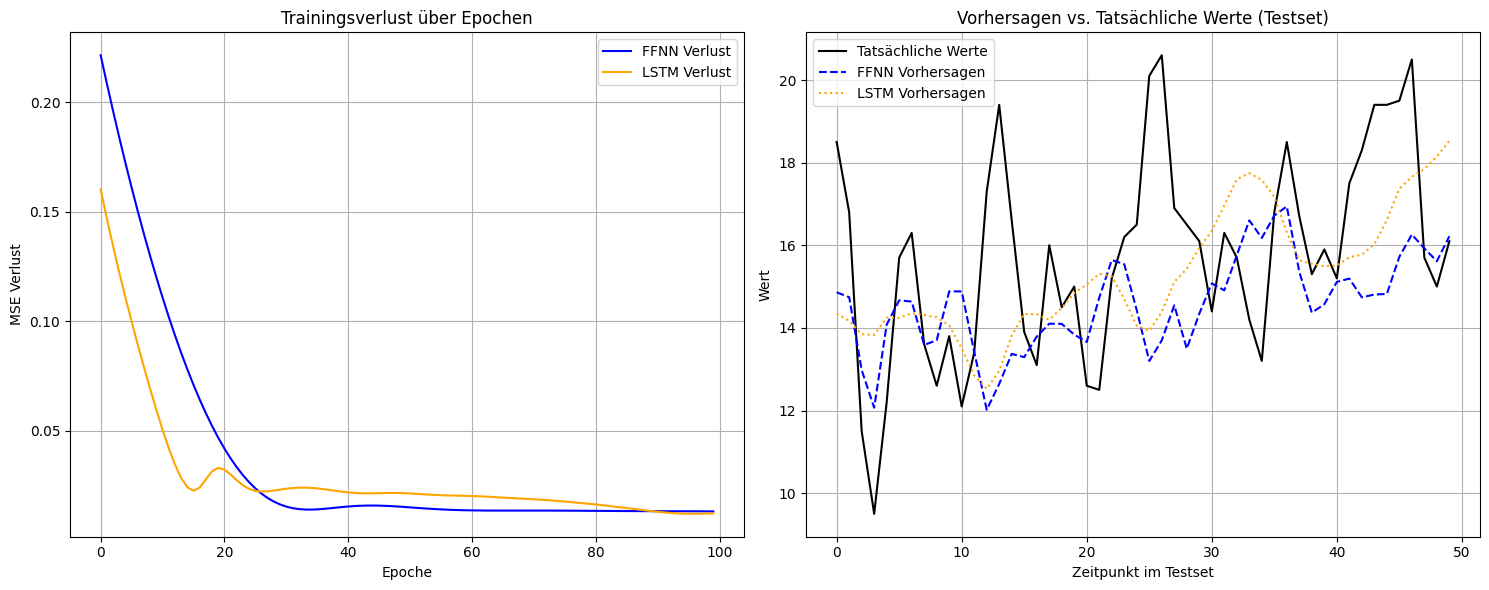

In [ ]:
print("\n--- Modellvergleich ---")
print(f"Naive FFNN RMSE: {ffnn_rmse:.6f}")
print(f"LSTM RMSE: {lstm_rmse:.6f}")

if lstm_rmse < ffnn_rmse:
    print(
        "Das LSTM-Modell hat eine bessere Leistung (niedrigeren RMSE) als das naive FFNN."
    )
else:
    print(
        "Das naive FFNN hat eine bessere oder gleiche Leistung (niedrigeren RMSE) wie das LSTM-Modell."
    )


# Visualisierungen der Vorhersagen

# Plot 1: Konvergenz der Trainingsverluste beider Modelle

# Plot 2: Vorhersagen im Vergleich zu den tatsächlichen Werten (Testset)
# Tip: Inverse Skalierung der Daten für eine verständlichere Visualisierung
